In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [2]:
df = pd.read_csv('../data/ethiopia.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Shape: (4108, 12)
Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


In [3]:
# Add country name
df['Country'] = 'Ethiopia'

# Replace -999 with NaN (NASA's missing value code)
df = df.replace(-999, np.nan)

# Check missing values
print("Missing values after replacing -999:")
print(df.isna().sum())

Missing values after replacing -999:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
dtype: int64


In [4]:
# Convert YEAR and DOY to datetime
df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')

# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df[['YEAR', 'DOY', 'Date', 'Month']].head()

Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


,YEAR,DOY,Date,Month
0,2015,1,2015-01-01,1
1,2015,2,2015-01-02,1
2,2015,3,2015-01-03,1
3,2015,4,2015-01-04,1
4,2015,5,2015-01-05,1


In [5]:
# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Dropped {duplicates} duplicates. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


In [6]:
# Summary statistics for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols].describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Month,Year
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,6.423564,2020.131451
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,3.477046,3.248907
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,1.000000,2015.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,3.000000,2017.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,6.000000,2020.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,9.000000,2023.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,12.000000,2026.000000


In [7]:
# Missing values report
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Percentage', ascending=False)

print("Columns with missing values:")
missing_report

Columns with missing values:


,Missing Count,Percentage


In [10]:
# Handle missing values using forward fill (carry forward previous day's value)
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

for col in weather_cols:
    if col in df.columns:
        df[col] = df[col].fillna('ffill')  # Changed: method='ffill' → 'ffill'

# Check remaining missing values
remaining = df[weather_cols].isna().sum().sum()
print(f"Remaining missing values after forward fill: {remaining}")

Remaining missing values after forward fill: 0


In [11]:
# Outlier detection using Z-scores
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

outlier_counts = {}
for col in outlier_cols:
    if col in df.columns:
        # Drop NaN for Z-score calculation
        clean_data = df[col].dropna()
        if len(clean_data) > 0:
            z_scores = np.abs(stats.zscore(clean_data))
            outliers = (z_scores > 3).sum()
            outlier_counts[col] = outliers
            print(f"{col}: {outliers} outliers detected")

print("\nNote: Outliers retained as they may represent real extreme weather events")

T2M: 3 outliers detected
T2M_MAX: 0 outliers detected
T2M_MIN: 18 outliers detected
PRECTOTCORR: 95 outliers detected
RH2M: 13 outliers detected
WS2M: 3 outliers detected
WS2M_MAX: 5 outliers detected

Note: Outliers retained as they may represent real extreme weather events


In [12]:
# Export cleaned data
df.to_csv('../data/ethiopia_clean.csv', index=False)
print("Cleaned data saved to: data/ethiopia_clean.csv")
print(f"Final shape: {df.shape}")

Cleaned data saved to: data/ethiopia_clean.csv
Final shape: (4108, 16)


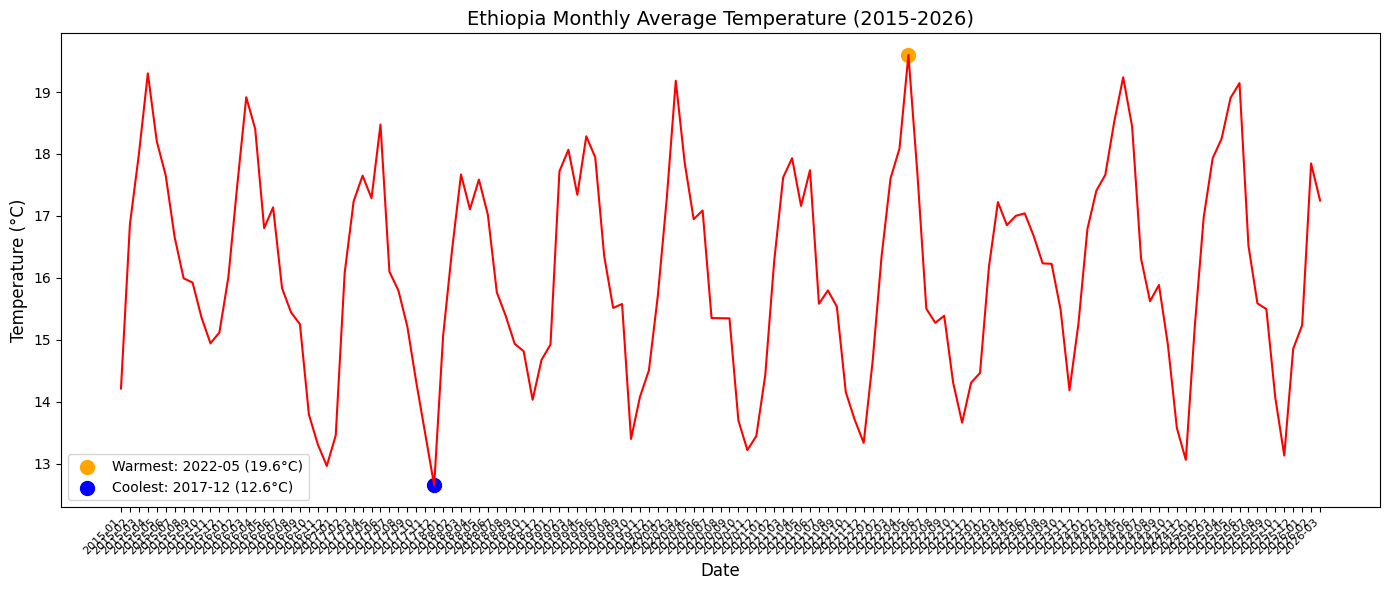

In [13]:
# Monthly average temperature time series
monthly_temp = df.groupby(df['Date'].dt.to_period('M'))['T2M'].mean()

plt.figure(figsize=(14, 6))
plt.plot(monthly_temp.index.astype(str), monthly_temp.values, linewidth=1.5, color='red')

# Annotate warmest and coolest
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()
plt.scatter(str(warmest), monthly_temp.max(), color='orange', s=100, label=f'Warmest: {warmest} ({monthly_temp.max():.1f}°C)')
plt.scatter(str(coolest), monthly_temp.min(), color='blue', s=100, label=f'Coolest: {coolest} ({monthly_temp.min():.1f}°C)')

plt.title('Ethiopia Monthly Average Temperature (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

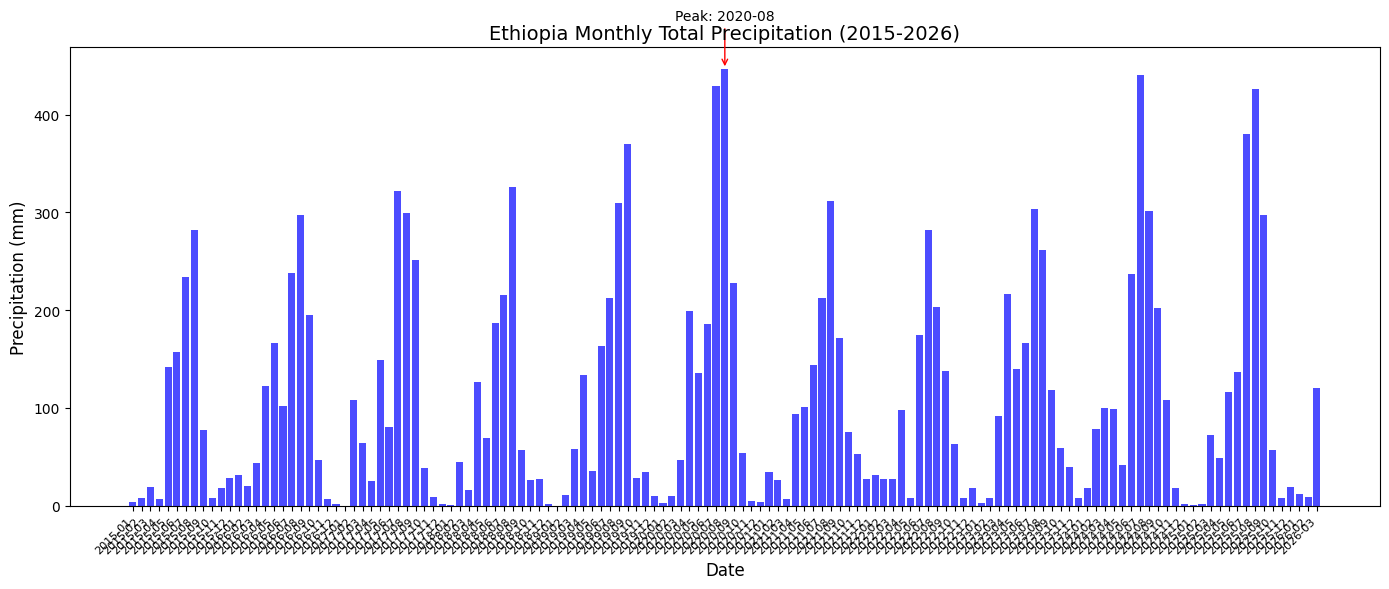

In [14]:
# Monthly total precipitation
monthly_precip = df.groupby(df['Date'].dt.to_period('M'))['PRECTOTCORR'].sum()

plt.figure(figsize=(14, 6))
plt.bar(monthly_precip.index.astype(str), monthly_precip.values, color='blue', alpha=0.7)

# Annotate peak rainy months
peak_month = monthly_precip.idxmax()
peak_value = monthly_precip.max()
plt.annotate(f'Peak: {peak_month}', xy=(str(peak_month), peak_value), 
             xytext=(str(peak_month), peak_value + 50),
             ha='center', fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

plt.title('Ethiopia Monthly Total Precipitation (2015-2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

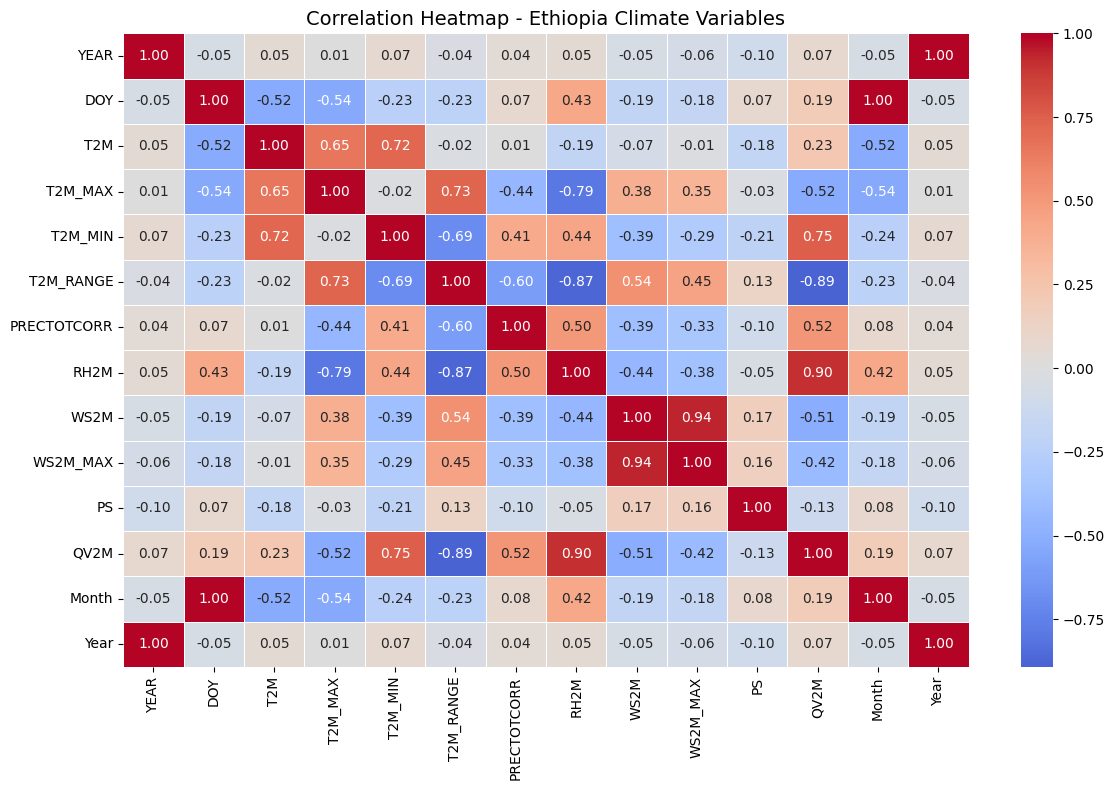


Top 3 strongest correlations:
Year      YEAR    1.000000
Month     DOY     0.996557
WS2M_MAX  WS2M    0.940826
dtype: float64


In [15]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap - Ethiopia Climate Variables', fontsize=14)
plt.tight_layout()
plt.show()

# Top 3 correlations
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper.unstack().dropna().sort_values(ascending=False).head(3)
print("\nTop 3 strongest correlations:")
print(top_corrs)

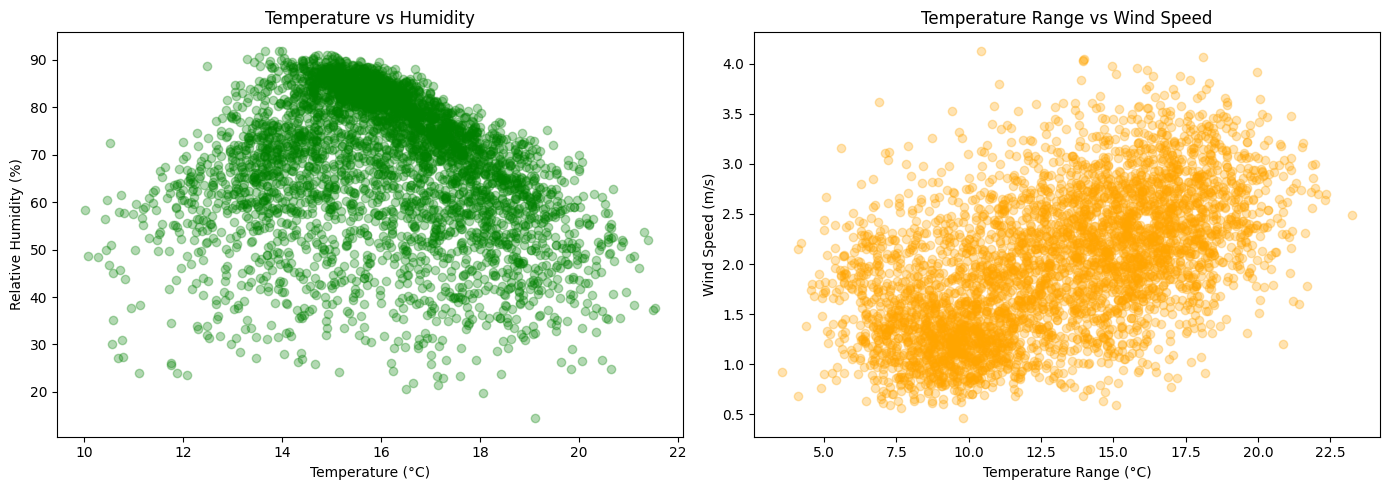

In [16]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# T2M vs RH2M
axes[0].scatter(df['T2M'], df['RH2M'], alpha=0.3, color='green')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Relative Humidity (%)')
axes[0].set_title('Temperature vs Humidity')

# T2M_RANGE vs WS2M
axes[1].scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.3, color='orange')
axes[1].set_xlabel('Temperature Range (°C)')
axes[1].set_ylabel('Wind Speed (m/s)')
axes[1].set_title('Temperature Range vs Wind Speed')

plt.tight_layout()
plt.show()

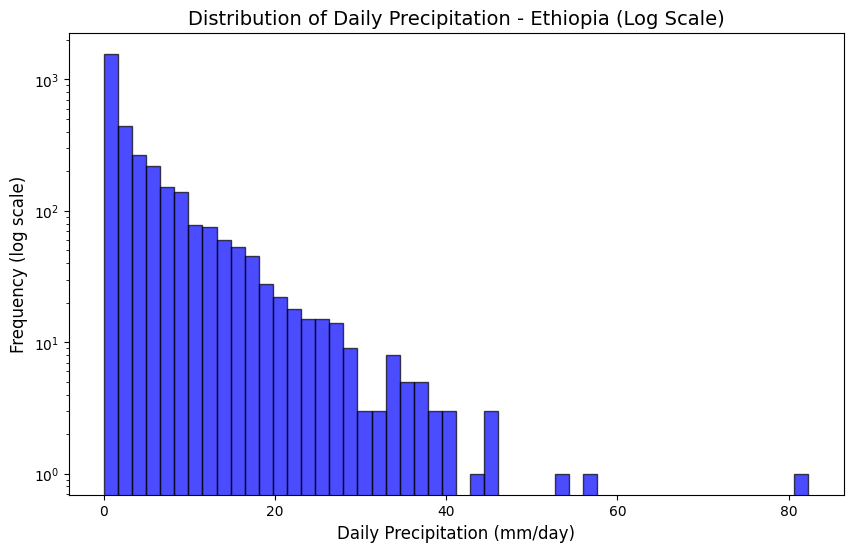

Most days have low precipitation (0-5 mm), with few extreme rainfall events


In [17]:
# Precipitation histogram (log scale)
plt.figure(figsize=(10, 6))

# Filter out zero or missing
precip_data = df['PRECTOTCORR'].dropna()
precip_data = precip_data[precip_data > 0]

plt.hist(precip_data, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Daily Precipitation (mm/day)', fontsize=12)
plt.ylabel('Frequency (log scale)', fontsize=12)
plt.title('Distribution of Daily Precipitation - Ethiopia (Log Scale)', fontsize=14)
plt.show()

print("Most days have low precipitation (0-5 mm), with few extreme rainfall events")